<a href="https://colab.research.google.com/github/hiralham/hiralham.github.io/blob/main/RCC_x_NSDC_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Identifying Bias in Data Workshop**

## Set-up:
Create a copy of this collab


Go to this link and click on the **Download** button to download a zip file of the dataset:
https://www.kaggle.com/datasets/ibrahimelsayed182/stanford-open-policing

Open the zip file in finder/file explorer, and double-click on it to **unzip** it. You should get a **.csv** file titled "police_data.csv"

In the collab, go to the **Files** tab to your left in the vertical toolbar. Click on the **upload** button and upload the unzipped file to this project.

###Import Libraries

In [ ]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###Import [Dataset](https://www.kaggle.com/datasets/ibrahimelsayed182/stanford-open-policing)

In [ ]:
file_id = '1TYmdWc1V4KQymhW48V5mF50sKR6WlNTm'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)

###Clean Dataset

In [ ]:
df.isna().sum()  #returns all the missing values from the dataset
df_clean = df.dropna(subset=['driver_gender', 'driver_age', 'driver_race', 'violation', 'stop_outcome', 'is_arrested', 'stop_duration']).copy()  #removed all missing values
df_clean.isna().sum()

,0
stop_date,0
stop_time,0
driver_gender,0
driver_age,0
driver_race,0
violation,0
search_conducted,0
stop_outcome,0
is_arrested,0
stop_duration,0


###Look at dataset

In [ ]:
# write your code here

In [ ]:
# write your code here

Finding the Mean

In [ ]:
overall_mean_search = df_clean['search_conducted'].mean() * 100
print(f'Overall Mean Search Rate: {overall_mean_search:.2f}%\n')

# Mean search rate grouped by driver race (Reveals group disparities)
search_mean_by_race = (
    df_clean.groupby('driver_race')['search_conducted'].mean() * 100
)
print('Mean Search Rate by Race (%):')
print(search_mean_by_race.round(2))


Overall Mean Search Rate: 3.71%

Mean Search Rate by Race (%):
driver_race
Asian       2.26
Black       6.47
Hispanic    6.16
Other       1.26
White       2.85
Name: search_conducted, dtype: float64


In [ ]:
mean_age = df_clean['driver_age'].mean()
print(mean_age.round(0))

34.0


Finding the Median

In [ ]:
median_age = df_clean['driver_age'].median()
print(median_age)

31.0


Finding the Mode

In [ ]:
mode_age = df_clean['driver_age'].mode()[0]
mode_violation = df_clean['violation'].mode()[0]

print(f"Most Common Age: {mode_age}")
print(f"Most Common Violation: {mode_violation}")

Most Common Age: 22.0
Most Common Violation: Speeding


Finding the Min, Max, and Range

In [ ]:
min_age = df_clean['driver_age'].min()
max_age = df_clean['driver_age'].max()
age_range = max_age - min_age

print(f"Min age: {min_age}")
print(f"Max age: {max_age}")
print(f"Range age: {age_range}")

Min age: 15.0
Max age: 99.0
Range age: 84.0


In [ ]:
top_5_ages = df_clean['driver_age'].nlargest(5)
top_5_ages

,driver_age
71539,99.0
75037,94.0
76956,90.0
74348,89.0
9829,88.0


In [ ]:
age_99 = (df_clean['driver_age'] == 99).sum()

print(df_clean['driver_age'].value_counts().get(99, 0))

1


### Counting, Proportions, & Measuring Disparities
* Before we get started, run the code cell below:

In [ ]:
from scipy.stats import chi2_contingency

def graph_race():

  # Plotting the above data
  stop_counts = df_clean['driver_race'].value_counts()

  # 2. Filter for ONLY searches conducted, THEN count by race
  search_counts = df_clean[df_clean['search_conducted'] == True]['driver_race'].value_counts()

  # 3. Combine into a single comparison DataFrame
  comparison_df = pd.DataFrame({'Stops': stop_counts, 'Searches': search_counts}).fillna(
    0
  )

  # 4. Plot using pandas / matplotlib
  ax = comparison_df.plot(kind='bar', figsize=(9, 5), color=['#1f77b4', '#ff7f0e'])

  plt.title(
    'Total Stops vs. Total Searches by Race', fontsize=13, fontweight='bold'
  )
  plt.xlabel('Driver Race')
  plt.ylabel('Number of Drivers')
  plt.xticks(rotation=0)
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.legend(title='')

# Optional: Add raw count numbers above the search bars so students can clearly see them
  for p in ax.patches:
      height = int(p.get_height())
      if height > 0:
          ax.annotate(
              f'{height:,}',
              (p.get_x() + p.get_width() / 2.0, height),
              ha='center',
              va='bottom',
              xytext=(0, 3),
              textcoords='offset points',
              fontsize=9,
          )

  plt.tight_layout()
  plt.show()

##############################


def race_rates():

  order = ["White", "Black", "Hispanic", "Asian", "Other"]

  # counts from your chart
  stops = pd.Series([62158, 12244, 9507, 2259, 240], index=order)
  searches = pd.Series([1768, 790, 584, 51, 3], index=order)

  # search rate = searches / stops
  rates = (searches / stops * 100).round(2)

  summary = pd.DataFrame({"Stops": stops, "Searches": searches, "Search rate (%)": rates})
  print(summary)

  # overall rate for a reference line
  overall = searches.sum() / stops.sum() * 100

  # chart
  fig, ax = plt.subplots(figsize=(9, 5))
  bars = ax.bar(rates.index, rates.values, color="#1f77b4")

  for bar, val in zip(bars, rates.values):
      ax.text(bar.get_x() + bar.get_width() / 2, val + 0.1,
              f"{val:.1f}%", ha="center", va="bottom", fontsize=10)

  ax.axhline(overall, color="gray", linestyle="--", linewidth=1)
  ax.text(len(order) - 0.5, overall + 0.1, f"Overall: {overall:.1f}%",
          ha="right", va="bottom", fontsize=9, color="gray")

  ax.set_title("Search Rate by Driver Race", fontweight="bold")
  ax.set_xlabel("Driver Race")
  ax.set_ylabel("% of Stops Resulting in a Search")
  ax.grid(axis="y", linestyle="--", alpha=0.6)
  ax.set_axisbelow(True)
  plt.tight_layout()
  plt.show()

#################################

def significance_test():

  order = ["White", "Black", "Hispanic", "Asian", "Other"]
  stops = pd.Series([62158, 12244, 9507, 2259, 240], index=order)
  searches = pd.Series([1768, 790, 584, 51, 3], index=order)

  table = pd.DataFrame({"searched": searches, "not_searched": stops - searches})

  chi2, p, dof, expected = chi2_contingency(table)
  if(p < 0.05):
    print("Statistically Significant")
    print(f"p = {p:.2e} < 0.05")
  else:
    print("Not Statistically Significant")
    print(f"p = {p:.2e} > 0.05")

##############

def graph_gender():
  """Compare how many men vs. women are stopped and searched,
  and how likely each group is to be searched once stopped."""

  # 1. Count stops and searches by gender
  stop_counts = df_clean['driver_gender'].value_counts()
  search_counts = df_clean[df_clean['search_conducted'] == True]['driver_gender'].value_counts()

  # 2. Combine into a single comparison DataFrame
  comparison_df = pd.DataFrame({'Stops': stop_counts, 'Searches': search_counts}).fillna(0)

  # 3. Plot the raw counts
  ax = comparison_df.plot(kind='bar', figsize=(7, 5), color=['#1f77b4', '#ff7f0e'])

  plt.title('Total Stops vs. Total Searches by Gender', fontsize=13, fontweight='bold')
  plt.xlabel('Driver Gender')
  plt.ylabel('Number of Drivers')
  plt.xticks(rotation=0)
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.legend(title='')

  for p in ax.patches:
      height = int(p.get_height())
      if height > 0:
          ax.annotate(
              f'{height:,}',
              (p.get_x() + p.get_width() / 2.0, height),
              ha='center',
              va='bottom',
              xytext=(0, 3),
              textcoords='offset points',
              fontsize=9,
          )

  plt.tight_layout()
  plt.show()

  # 4. Plot the search RATE (searches / stops) so the groups are comparable
  rates = (comparison_df['Searches'] / comparison_df['Stops'] * 100).round(2)

  fig, ax2 = plt.subplots(figsize=(7, 5))
  bars = ax2.bar(rates.index, rates.values, color='#1f77b4')
  for bar, val in zip(bars, rates.values):
      ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.05,
               f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

  ax2.set_title('Search Rate by Driver Gender', fontweight='bold')
  ax2.set_xlabel('Driver Gender')
  ax2.set_ylabel('% of Stops Resulting in a Search')
  ax2.grid(axis='y', linestyle='--', alpha=0.6)
  ax2.set_axisbelow(True)
  plt.tight_layout()
  plt.show()

########################
def graph(column):
  """Graph stops vs. searches for ANY column in the dataset.

  column: name of the column as a string, e.g. "driver_age" or "violation"

  Examples:
    graph("driver_age")
    graph("violation")
    graph("stop_outcome")
  """

  top_n = 10       # text columns: only show the 10 most common categories
  bins = 8         # number columns (like age): split into 8 ranges
  show_rate = True # also draw the search-rate chart

  # Check the column exists
  if column not in df_clean.columns:
    print(f'"{column}" is not a column in this dataset.')
    print('Try one of these:', list(df_clean.columns))
    return

  data = df_clean[[column, 'search_conducted']].dropna(subset=[column]).copy()
  data['searched'] = (data['search_conducted'] == True)
  note = ''

  # Number columns with many values (like age) get grouped into ranges
  if pd.api.types.is_numeric_dtype(data[column]) and data[column].nunique() > 10:
    low, high = data[column].quantile([0.01, 0.99])
    data = data[(data[column] >= low) & (data[column] <= high)]
    groups = pd.cut(data[column], bins=bins)
    summary = data.groupby(groups, observed=True)['searched'].agg(['size', 'sum'])
    summary.index = [f'{int(i.left)}-{int(i.right)}' for i in summary.index]
    note = ' (grouped into ranges)'
  # Text columns: keep the most common categories
  else:
    summary = data.groupby(column)['searched'].agg(['size', 'sum'])
    summary = summary.sort_values('size', ascending=False).head(top_n)
    if data[column].nunique() > top_n:
      note = f' (top {top_n})'

  summary.columns = ['Stops', 'Searches']
  label = column.replace('_', ' ').title()

  # Chart 1: raw counts
  ax = summary.plot(kind='bar', figsize=(max(8, len(summary) * 1.1), 5),
                    color=['#1f77b4', '#ff7f0e'])
  plt.title(f'Total Stops vs. Total Searches by {label}{note}',
            fontsize=13, fontweight='bold')
  plt.xlabel(label)
  plt.ylabel('Number of Drivers')
  plt.xticks(rotation=45 if len(summary) > 5 else 0, ha='right' if len(summary) > 5 else 'center')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.legend(title='')

  for p in ax.patches:
      height = int(p.get_height())
      if height > 0:
          ax.annotate(f'{height:,}',
                      (p.get_x() + p.get_width() / 2.0, height),
                      ha='center', va='bottom', xytext=(0, 3),
                      textcoords='offset points', fontsize=8)

  plt.tight_layout()
  plt.show()

  # Chart 2: search rate
  if show_rate:
    rates = (summary['Searches'] / summary['Stops'] * 100).round(2)
    overall = summary['Searches'].sum() / summary['Stops'].sum() * 100

    fig, ax2 = plt.subplots(figsize=(max(8, len(summary) * 1.1), 5))
    bars = ax2.bar(rates.index.astype(str), rates.values, color='#1f77b4')
    for bar, val in zip(bars, rates.values):
        ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.05,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    ax2.axhline(overall, color='gray', linestyle='--', linewidth=1)
    ax2.text(len(rates) - 0.5, overall + 0.05, f'Overall: {overall:.1f}%',
             ha='right', va='bottom', fontsize=9, color='gray')

    ax2.set_title(f'Search Rate by {label}{note}', fontweight='bold')
    ax2.set_xlabel(label)
    ax2.set_ylabel('% of Stops Resulting in a Search')
    ax2.grid(axis='y', linestyle='--', alpha=0.6)
    ax2.set_axisbelow(True)
    plt.xticks(rotation=45 if len(summary) > 5 else 0, ha='right' if len(summary) > 5 else 'center')
    plt.tight_layout()
    plt.show()

######################

def count_stops(column):
    """How many stops fall into each group."""
    return df_clean[column].value_counts()
##############

def count_searches(column):
    """How many searches fall into each group."""
    return df_clean[df_clean["search_conducted"]][column].value_counts()

################

def stop_share(column):
    """Each group's % of all stops."""
    return (df_clean[column].value_counts(normalize=True) * 100).round(1)

####################

def search_share(column):
    """Each group's % of all searches."""
    searched = df_clean[df_clean["search_conducted"]]
    return (searched[column].value_counts(normalize=True) * 100).round(1)

################

def search_rate(column):
    """% of each group's stops that led to a search."""
    return (df_clean.groupby(column)["search_conducted"].mean() * 100).round(2)

##################

def make_chart(numbers, title):
    """Bar chart of any result from the tools above."""
    ax = numbers.plot(kind="bar", color="#4C72B0", figsize=(6, 4))
    ax.bar_label(ax.containers[0])
    ax.set_title(title)
    ax.set_xlabel("")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

####################

def significance_test(column):
    """Could the difference in search rates between groups be due to chance?"""
    table = pd.crosstab(df_clean[column], df_clean["search_conducted"])
    p = chi2_contingency(table)[1]
    print(f"p-value: {p:.3g}")
    if p < 0.05:
        print("p < 0.05 → a difference this big is very unlikely to be chance")
    else:
        print("p ≥ 0.05 → the difference could be due to chance")

##################

print("All functions downloaded.")


All functions downloaded.


### Counting 🔢
* Identify **the count** of drivers who are stopped and searched.

In [ ]:
# write your code here

### Proportions ⚖️
*   Identify **the percentage** of drivers that are. stopped are also searched.

In [ ]:
# write your code here

### Measuring Disparities Part 1 📊
* Among those stopped and searched, what is the racial breakdown?

In [ ]:
# write your code here

### Measuring Disparities Part 2 📊


*   What are the rates at which each racial group is searched?

In [ ]:
# write your code here

### Measuring Disparities Part 3 📊

* Assuming there is no relationship between race and being searched, how likely is it that we would observe results this extreme?

In [ ]:
# write your code here

###CHALLENGE 1 🎯
Imagine two drivers get pulled over on the same highway, on the same night.
One is a **man** and another is a **woman**.

> ## Is gender bias present here? Is one gender more likely to be searched than another?

Steps:
1. Explore the data
2. Create Visualizations
3. Test

# 🧰 Your Toolbox

| Tool | What it tells you | Concept |
|---|---|---|
| `count_stops('column')` | How many **stops** fall into each group | Counting |
| `count_searches('column')` | How many **searches** fall into each group | Counting |
| `stop_share('column')` | Each group's **% of all stops** | Proportion |
| `search_share('column')` | Each group's **% of all searches** | Proportion |
| `search_rate('column')` | **% of each group's stops** that led to a search | Rate |
| `make_chart(result, 'title')` | Turns **any result above** into a bar chart | Graphing |
| `significance_test('column')` | Could the difference in search rates be **due to chance?** | Significance |

 * Every tool takes a **column name** in quotes, e.g. `count_stops('driver_gender')`. You can use them on **any** column!

* ⚠️ **Think before you run!** Several of these tools compare men and women, but they don't all measure the same thing. Which one(s) answers *the question we care about*?

**Example for make_chart(result, 'title'):**

`make_chart(count_stops('driver_gender'), 'Total stops by driver gender')`

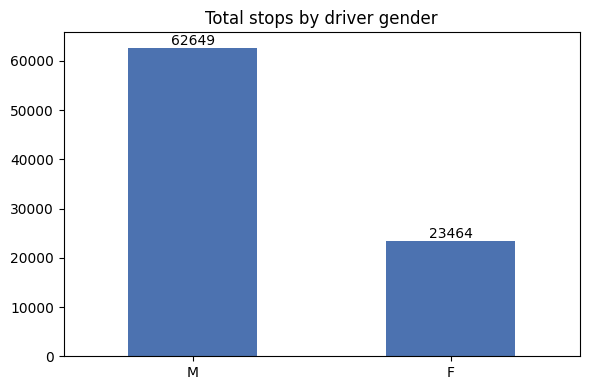

In [ ]:
# write your code here

###CHALLENGE 2 🎯
*   Explore to find any other factors that can play a role in the likelihood of someone being searched when they are stopped by the police in Rhode Island.



In [ ]:
# write your code here